# Academic Performance Regression

I wanted to check how much CGPA can be explained by three simple factors: sleep, attendance, and screen time.

The model here is intentionally simple. It is just multiple linear regression, with a few plots to make the relationships easier to understand.


## Imports


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)


## Load Data


In [2]:
plots_dir = Path("outputs/plots")
results_dir = Path("outputs/results")

plots_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("student_data_700.csv")

print("Columns:", df.columns.tolist())
print("Rows:", len(df))
df.head()


Columns: ['CGPA', 'SLP', 'ATT', 'SCR']
Rows: 750


,CGPA,SLP,ATT,SCR
0,6.2300,6.2000,84,5.6000
1,5.4400,5.6000,71,7.3000
2,6.6600,6.3000,75,4.4000
3,8.0700,8.0000,87,4.9000
4,6.4400,5.8000,72,5.2000


## Clean the Data

The only slightly annoying part is screen time. If it ever appears as a range, I convert the range into its midpoint.


In [3]:
def parse_range(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    try:
        if "-" in x:
            low, high = x.split("-")
            return (float(low) + float(high)) / 2
        return float(x)
    except Exception:
        return np.nan


df["SCR"] = df["SCR"].apply(parse_range)

for col in ["CGPA", "SLP", "ATT"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

X = df[["SLP", "ATT", "SCR"]].to_numpy(dtype=float)
y = df["CGPA"].to_numpy(dtype=float)

mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X = X[mask]
y = y[mask]

clean_df = df.loc[mask, ["CGPA", "SLP", "ATT", "SCR"]].copy()
clean_df.to_csv(results_dir / "cleaned_student_data.csv", index=False)

print("Total responses:", df.shape[0])
print("Usable responses:", len(y))
clean_df.head()


Total responses: 750
Usable responses: 750


,CGPA,SLP,ATT,SCR
0,6.2300,6.2000,84,5.6000
1,5.4400,5.6000,71,7.3000
2,6.6600,6.3000,75,4.4000
3,8.0700,8.0000,87,4.9000
4,6.4400,5.8000,72,5.2000


## Quick Summary


In [4]:
summary = clean_df.describe().T
summary.to_csv(results_dir / "summary_statistics.csv")
summary


,count,mean,std,min,25%,50%,75%,max
CGPA,750.0000,6.4436,0.7355,5.0000,5.9100,6.4200,6.9300,8.8500
SLP,750.0000,6.5599,0.8328,4.0000,6.0000,6.6000,7.1000,9.0000
ATT,750.0000,74.8987,10.0916,40.0000,68.0000,75.0000,81.0000,100.0000
SCR,750.0000,6.0291,1.0266,2.9000,5.4000,6.0500,6.7000,9.4000


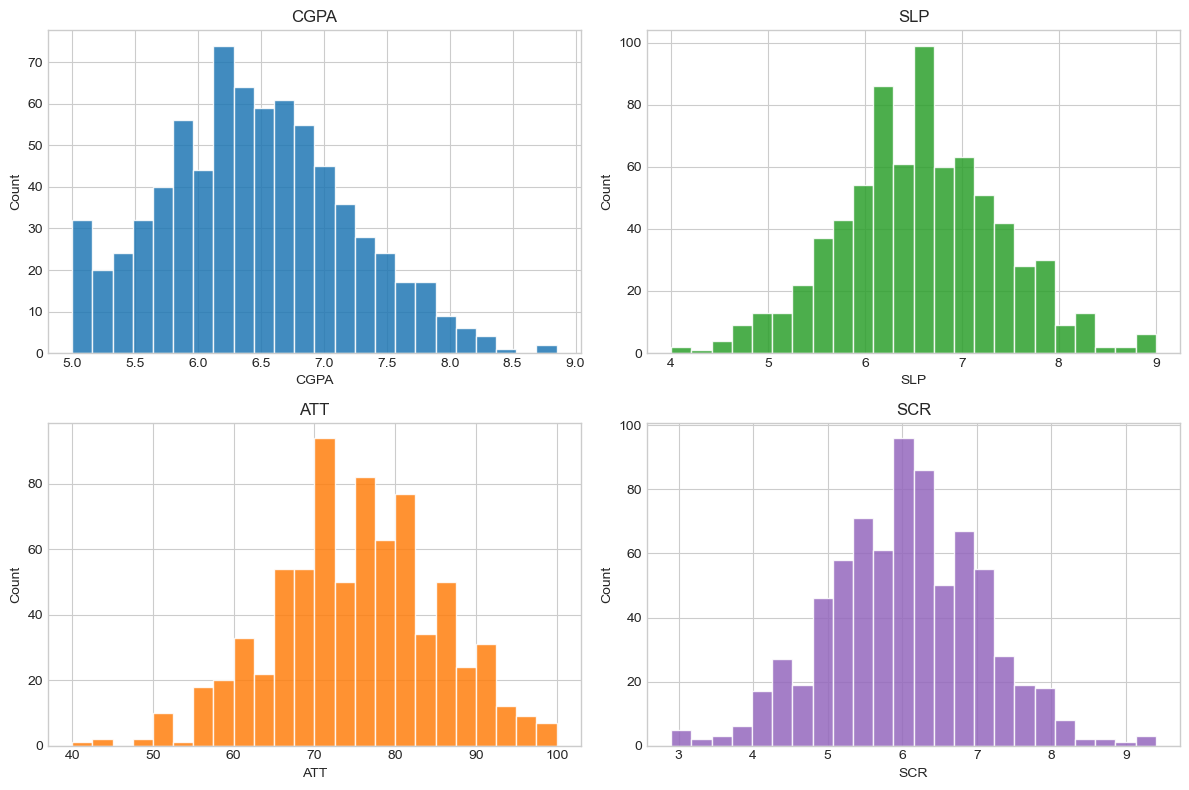

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
columns = ["CGPA", "SLP", "ATT", "SCR"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd"]

for ax, col, color in zip(axes.ravel(), columns, colors):
    ax.hist(clean_df[col], bins=24, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(plots_dir / "feature_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


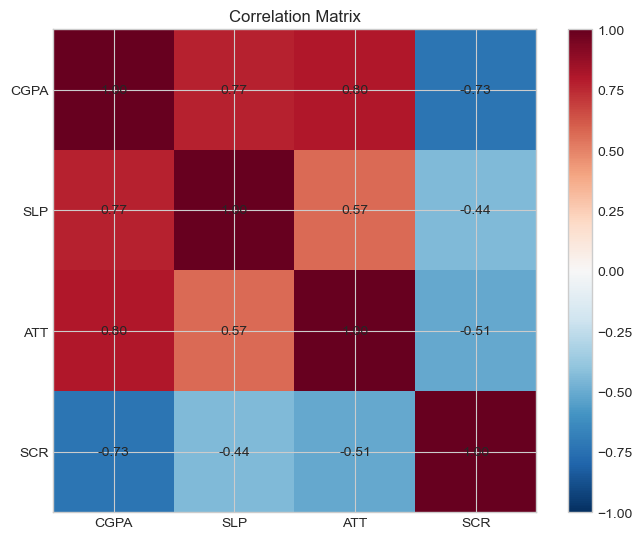

In [6]:
corr = clean_df[["CGPA", "SLP", "ATT", "SCR"]].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)), corr.columns)
ax.set_yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Matrix")
plt.colorbar(image, ax=ax)
plt.tight_layout()
plt.savefig(plots_dir / "correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


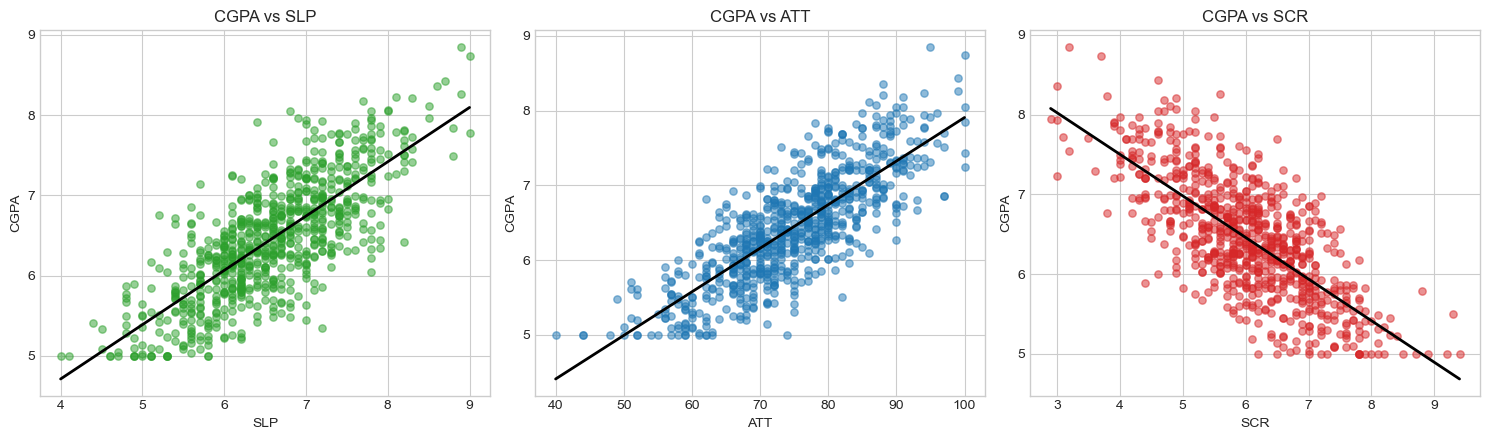

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, color in zip(axes, ["SLP", "ATT", "SCR"], ["#2ca02c", "#1f77b4", "#d62728"]):
    ax.scatter(clean_df[col], clean_df["CGPA"], alpha=0.5, s=28, color=color)

    m, b = np.polyfit(clean_df[col], clean_df["CGPA"], 1)
    x_line = np.linspace(clean_df[col].min(), clean_df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=2)

    ax.set_xlabel(col)
    ax.set_ylabel("CGPA")
    ax.set_title(f"CGPA vs {col}")

plt.tight_layout()
plt.savefig(plots_dir / "feature_relationships.png", dpi=200, bbox_inches="tight")
plt.show()


## Standardize and Split

I standardize the three input features so that the coefficients are easier to compare.


In [8]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_std,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training rows:", len(y_train))
print("Testing rows:", len(y_test))


Training rows: 600
Testing rows: 150


## Train the Model


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

metrics = pd.DataFrame(
    {
        "Metric": ["R2", "RMSE", "MAE", "Test Observations"],
        "Value": [r2, rmse, mae, len(y_test)],
    }
)
metrics.to_csv(results_dir / "model_metrics.csv", index=False)
metrics


R2: 0.8618934523481346
RMSE: 0.2715976314834504
MAE: 0.21890962711140674


,Metric,Value
0,R2,0.8619
1,RMSE,0.2716
2,MAE,0.2189
3,Test Observations,150.0000


In [10]:
coef_df = pd.DataFrame(
    {
        "Feature": ["SLP", "ATT", "SCR"],
        "Coefficient": model.coef_,
    }
).sort_values("Coefficient", ascending=False)

coef_df.to_csv(results_dir / "model_coefficients.csv", index=False)

print("Intercept:", model.intercept_)
coef_df


Intercept: 6.441947128288147


,Feature,Coefficient
1,ATT,0.3036
0,SLP,0.2715
2,SCR,-0.2673


## Prediction Checks


In [11]:
predictions = pd.DataFrame(
    {
        "Actual CGPA": y_test,
        "Predicted CGPA": y_pred,
        "Residual": y_test - y_pred,
    }
)
predictions.to_csv(results_dir / "test_predictions.csv", index=False)

predictions.head()


,Actual CGPA,Predicted CGPA,Residual
0,6.4500,6.3546,0.0954
1,5.8900,6.4684,-0.5784
2,7.5100,7.1320,0.3780
3,5.4800,5.3442,0.1358
4,6.9800,6.6625,0.3175


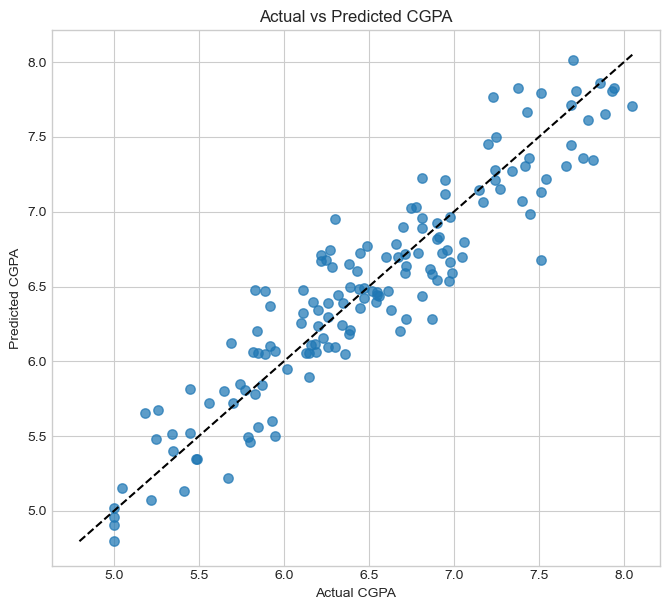

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 6.2))

ax.scatter(predictions["Actual CGPA"], predictions["Predicted CGPA"], alpha=0.72, s=46)

low = min(predictions["Actual CGPA"].min(), predictions["Predicted CGPA"].min())
high = max(predictions["Actual CGPA"].max(), predictions["Predicted CGPA"].max())
ax.plot([low, high], [low, high], color="black", linestyle="--")

ax.set_xlabel("Actual CGPA")
ax.set_ylabel("Predicted CGPA")
ax.set_title("Actual vs Predicted CGPA")

plt.tight_layout()
plt.savefig(plots_dir / "actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()


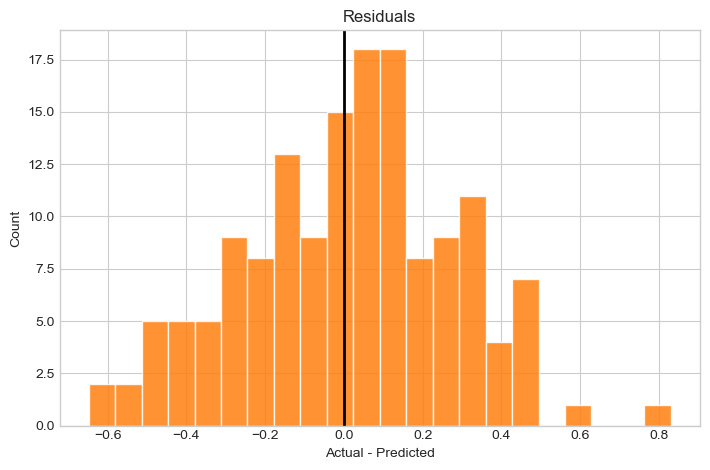

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.hist(predictions["Residual"], bins=22, color="#ff7f0e", alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=2)
ax.set_xlabel("Actual - Predicted")
ax.set_ylabel("Count")
ax.set_title("Residuals")

plt.tight_layout()
plt.savefig(plots_dir / "residuals_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


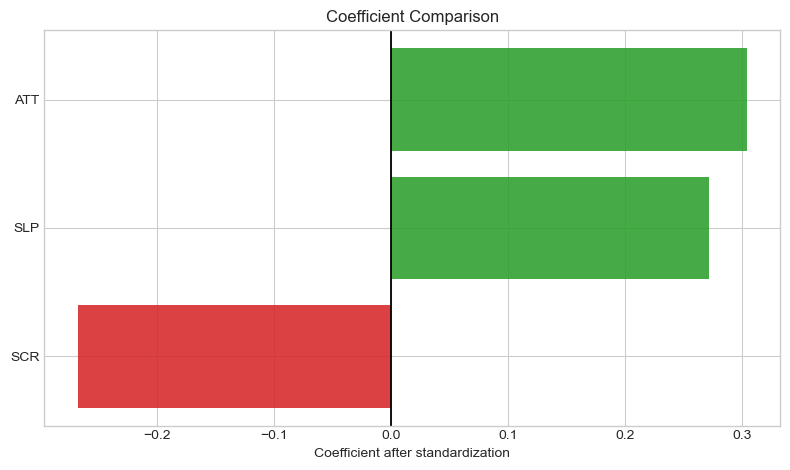

In [14]:
plot_coef = coef_df.sort_values("Coefficient")
colors = ["#d62728" if c < 0 else "#2ca02c" for c in plot_coef["Coefficient"]]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(plot_coef["Feature"], plot_coef["Coefficient"], color=colors, alpha=0.88)
ax.axvline(0, color="black", linewidth=1.3)
ax.set_xlabel("Coefficient after standardization")
ax.set_title("Coefficient Comparison")

plt.tight_layout()
plt.savefig(plots_dir / "coefficient_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 3D Regression Plane

For this plot, screen time is fixed at its average standardized value. Then I plot sleep, attendance, and CGPA around that conditional plane.


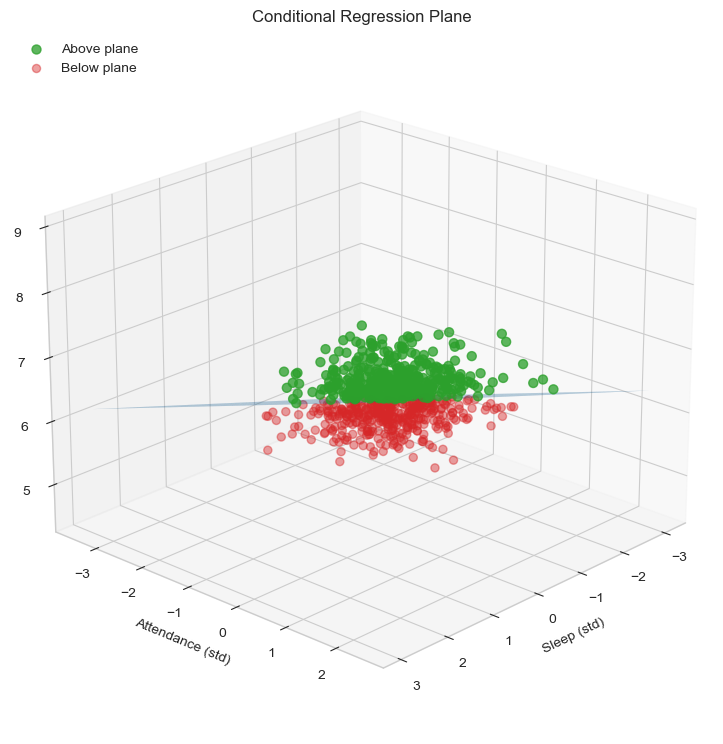

In [15]:
SCR_mean = X_std[:, 2].mean()

x1_surf, x2_surf = np.meshgrid(
    np.linspace(X_std[:, 0].min(), X_std[:, 0].max(), 50),
    np.linspace(X_std[:, 1].min(), X_std[:, 1].max(), 50),
)

y_surf = (
    model.intercept_
    + model.coef_[0] * x1_surf
    + model.coef_[1] * x2_surf
    + model.coef_[2] * SCR_mean
)

y_plane_pred = (
    model.intercept_
    + model.coef_[0] * X_std[:, 0]
    + model.coef_[1] * X_std[:, 1]
    + model.coef_[2] * SCR_mean
)

above_plane = y >= y_plane_pred
below_plane = ~above_plane

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_std[above_plane, 0],
    X_std[above_plane, 1],
    y[above_plane],
    s=42,
    alpha=0.76,
    color="#2ca02c",
    label="Above plane",
)

ax.scatter(
    X_std[below_plane, 0],
    X_std[below_plane, 1],
    y[below_plane],
    s=34,
    alpha=0.44,
    color="#d62728",
    label="Below plane",
)

ax.plot_surface(x1_surf, x2_surf, y_surf, color="#1f77b4", alpha=0.32, linewidth=0)

ax.set_xlabel("Sleep (std)")
ax.set_ylabel("Attendance (std)")
ax.set_zlabel("CGPA", labelpad=12)
ax.set_title("Conditional Regression Plane")
ax.legend(loc="upper left")
ax.view_init(elev=22, azim=43)

fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)
plt.savefig(plots_dir / "conditional_regression_plane.png", dpi=200)
plt.show()


## What I Took From This


In [16]:
print(f"R2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print()

for row in coef_df.itertuples(index=False):
    sign = "positive" if row.Coefficient > 0 else "negative"
    print(f"{row.Feature}: {sign} coefficient ({row.Coefficient:.4f})")


R2: 0.8619
RMSE: 0.2716

ATT: positive coefficient (0.3036)
SLP: positive coefficient (0.2715)
SCR: negative coefficient (-0.2673)


Attendance and sleep come out positive, while screen time comes out negative. That matches the basic intuition I had before running the model.

The important catch is that this is still just regression on a synthetic dataset. It shows a pattern in this data, not a real causal claim.
